This code identifies events in the sphere which are coincident with events in the veto system!

In [10]:
#import the datasets
import pandas as pd
import matplotlib.pyplot as plt # https://matplotlib.org/
import numpy as np # http://www.numpy.org/


#load data
df = pd.read_csv("Ac12h002.csv")

#keep columns we care about
df = df[['event', 'anode', 'amplitude', 'risetime']].copy()

#ensure numeric
df['amplitude'] = pd.to_numeric(df['amplitude'], errors='coerce')
df['risetime'] = pd.to_numeric(df['risetime'], errors='coerce')

amp_df = df.pivot_table(index='event', columns='anode', values='amplitude', aggfunc='first')
amp_df = amp_df.rename(columns={col: f"{col}_amplitude" for col in amp_df.columns})

rise_df = df.pivot_table(index='event', columns='anode', values='risetime', aggfunc='first')
rise_df = rise_df.rename(columns={col: f"{col}_risetime" for col in rise_df.columns})

#combine into one dataframe
event_df = pd.concat([amp_df, rise_df], axis=1).reset_index()

#check
#print(event_df.head())
#print("Columns:", event_df.columns.tolist())

#identify anode with highest amplitude for each anode
sphere_amplitude_cols = [col for col in event_df.columns if col.endswith('_amplitude') and not col.startswith('Laser')]
event_df['max_anode'] = event_df[sphere_amplitude_cols].idxmax(axis=1)
#identify which risetime corresponds to this anode and event
event_df['max_anode'] = event_df['max_anode'].str.replace('_amplitude', '', regex=False)
event_df['risetime'] = [event_df.loc[i, f"{anode}_risetime"] if pd.notna(anode) else np.nan for i, anode in event_df['max_anode'].items()]

#sum together all of the sphere anode amplitudes and create a new column of 'summed_amplitude'
event_df['summed_amplitude'] = event_df[sphere_amplitude_cols].sum(axis=1)

print(event_df.columns)

Index(['event', 'F0_amplitude', 'F1_amplitude', 'F2_amplitude', 'F3_amplitude',
       'F4_amplitude', 'F5_amplitude', 'Laser_amplitude', 'N1_amplitude',
       'N2_amplitude', 'N3_amplitude', 'N4_amplitude', 'N5_amplitude',
       'F0_risetime', 'F1_risetime', 'F2_risetime', 'F3_risetime',
       'F4_risetime', 'F5_risetime', 'Laser_risetime', 'N1_risetime',
       'N2_risetime', 'N3_risetime', 'N4_risetime', 'N5_risetime', 'max_anode',
       'risetime', 'summed_amplitude'],
      dtype='object', name='anode')


In [25]:
#some of the veto rows will be empty - only keep if amplitude above some nominal noise, say 200ADU
events_in_veto = event_df[event_df['Laser_amplitude'] > 200]

#delete these events from the data frame
muons_removed_df = event_df[event_df['Laser_amplitude'] <= 200]

print("Max summed amplitude:", event_df['summed_amplitude'].max())

Max summed amplitude: 462962.6111111111


<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:30: SyntaxWarning: invalid escape sequence '\m'
<>:47: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:30: SyntaxWarning: invalid escape sequence '\m'
<>:47: SyntaxWarning: invalid escape sequence '\m'
/var/folders/54/shy8r4g15d33hf9px0m5hytc0000gn/T/ipykernel_74576/1941405059.py:13: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel(f'Rise Time ($\mu$s)')
/var/folders/54/shy8r4g15d33hf9px0m5hytc0000gn/T/ipykernel_74576/1941405059.py:30: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel(f'Rise Time ($\mu$s)')
/var/folders/54/shy8r4g15d33hf9px0m5hytc0000gn/T/ipykernel_74576/1941405059.py:47: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel(f'Rise Time ($\mu$s)')


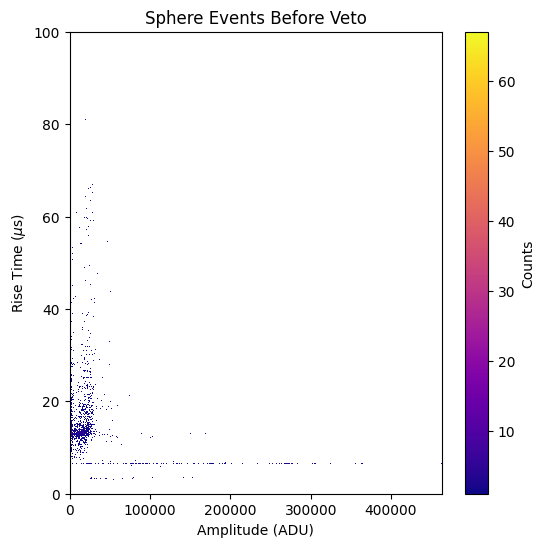

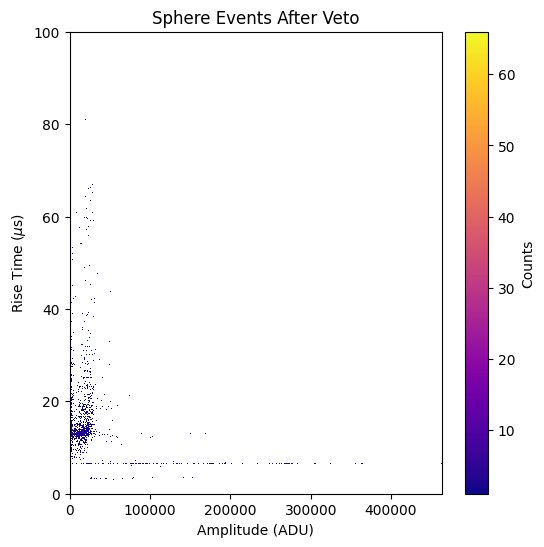

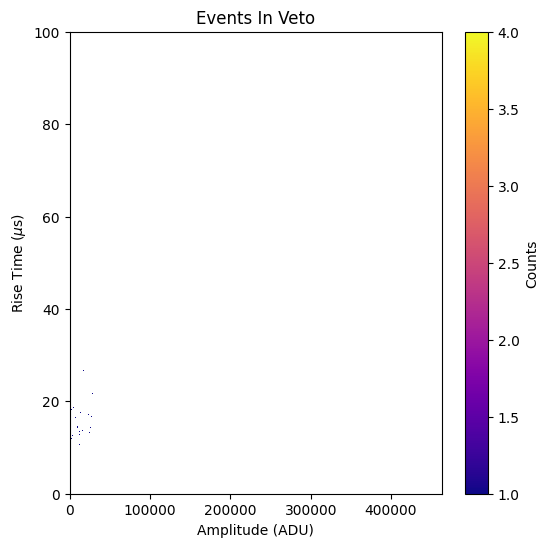

In [26]:
#print the rise-time amplitude plots!
plt.figure(figsize=(6,6))
h = plt.hist2d(
    event_df['summed_amplitude'], 
    event_df['risetime'], 
    bins=1000,
    range=[[0,event_df['summed_amplitude'].max()],[0,100]],
    density=False, 
    cmap='plasma',
    cmin=1
)
plt.title("Sphere Events Before Veto")
plt.ylabel(f'Rise Time ($\mu$s)')
plt.xlabel('Amplitude (ADU)')
plt.colorbar(h[3], label='Counts')  # colorbar
plt.show()


plt.figure(figsize=(6,6))
h = plt.hist2d(
    muons_removed_df['summed_amplitude'], 
    muons_removed_df['risetime'], 
    bins=1000,
    range=[[0,event_df['summed_amplitude'].max()],[0,100]],
    density=False, 
    cmap='plasma',
    cmin=1
)
plt.title("Sphere Events After Veto")
plt.ylabel(f'Rise Time ($\mu$s)')
plt.xlabel('Amplitude (ADU)')
plt.colorbar(h[3], label='Counts')  # colorbar
plt.show()


plt.figure(figsize=(6,6))
h = plt.hist2d(
    events_in_veto['summed_amplitude'], 
    events_in_veto['risetime'], 
    bins=1000,
    range=[[0,event_df['summed_amplitude'].max()],[0,100]],
    density=False, 
    cmap='plasma',
    cmin=1
)
plt.title("Events In Veto")
plt.ylabel(f'Rise Time ($\mu$s)')
plt.xlabel('Amplitude (ADU)')
plt.colorbar(h[3], label='Counts')  # colorbar
plt.show()